# Sesión 7 · Actividad 1  
# Anatomía de un prompt: descubrir cómo una IA interpreta instrucciones

**Curso:** Introducción a la Inteligencia Artificial Generativa  
**Modalidad:** laboratorio guiado en Google Colab

---

## Instrucciones:

En esta actividad experimentarás con un modelo de difusión para observar cómo cambia una imagen cuando agregas información progresivamente a un prompt.

No necesitas comprender ecuaciones ni modificar código complejo. Tu tarea será:

1. formular una predicción;
2. ejecutar una generación;
3. observar el resultado;
4. comparar;
5. explicar qué cambió.

> **Idea central de la actividad:** cambiar una sola variable a la vez permite atribuir los cambios observados al prompt.

# 0. Preparación

En Google Colab selecciona:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después ejecuta las celdas en orden.

> La primera ejecución puede tardar más porque Colab necesita descargar el modelo.

In [1]:
# Verificación del entorno
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "No se detectó una GPU. Selecciona: "
        "Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
    )

Versión de PyTorch: 2.11.0+cu128
GPU disponible: True
GPU detectada: Tesla T4


## Guardado opcional en Google Drive

El cuaderno puede guardar los resultados de dos formas:

- temporalmente dentro de Colab;
- de manera permanente en Google Drive.

La segunda opción es recomendable si deseas conservar las imágenes después de cerrar la sesión.

In [2]:
# Ejecuta esta celda solo si deseas guardar en Google Drive.
# Colab solicitará autorización.

USAR_DRIVE = False  # Cambia a True para guardar en tu Drive

from pathlib import Path

if USAR_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    CARPETA_RESULTADOS = Path(
        "/content/drive/MyDrive/IA_Generativa/Sesion7/Actividad1_Resultados"
    )
else:
    CARPETA_RESULTADOS = Path("/content/resultados_actividad1")

CARPETA_RESULTADOS.mkdir(parents=True, exist_ok=True)
print("Los resultados se guardarán en:", CARPETA_RESULTADOS)

Los resultados se guardarán en: /content/resultados_actividad1


# 1. Instalación de bibliotecas

Usaremos **Diffusers**, una biblioteca especializada en modelos de difusión.

In [3]:
!pip -q install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 92.1 MB/s eta 0:00:00


# 2. Carga del modelo

Usaremos Stable Diffusion 1.5 porque puede ejecutarse en una GPU gratuita de Colab y permite controlar los parámetros que estudiaremos durante la sesión.



In [4]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    use_safetensors=True,
    safety_checker=None
)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_attention_slicing()

print("Modelo cargado correctamente.")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado correctamente.


# 3. Diseño del experimento

Para comparar de forma justa mantendremos constantes:

- semilla;
- número de pasos;
- guidance scale;
- tamaño de imagen.

La única variable que cambia será el prompt.



In [15]:
SEED = 100
STEPS = 25
GUIDANCE = 7.5
WIDTH = 512
HEIGHT = 512

def generar_imagen(prompt, nombre_archivo):
    generator = torch.Generator(device="cuda").manual_seed(SEED)

    imagen = pipe(
        prompt=prompt,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        width=WIDTH,
        height=HEIGHT,
        generator=generator
    ).images[0]

    ruta = CARPETA_RESULTADOS / f"{nombre_archivo}.png"
    imagen.save(ruta)
    return imagen

print("Función de generación preparada.")

Función de generación preparada.


# 4. Experimento guiado

Antes de ejecutar cada prompt:

1. predice qué cambiará;
2. anota tu predicción;
3. ejecuta la celda;
4. compara con la imagen anterior;
5. registra qué cambió realmente.



## Paso 1 · Sujeto

**Prompt**

> `A cat`

**Predicción:** ¿Qué decisiones tendrá que tomar el modelo por sí solo?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

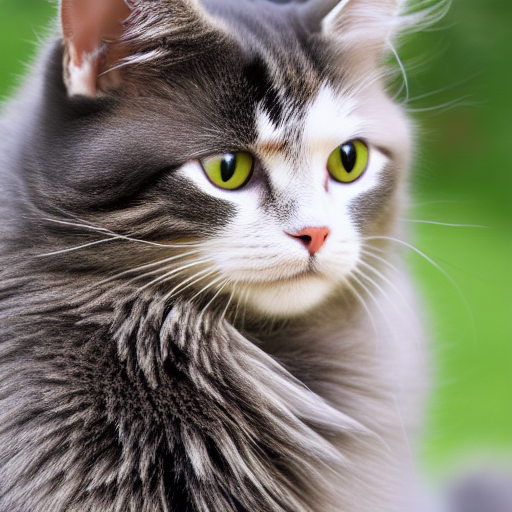

In [16]:
prompt_1 = 'A cat'
imagen_1 = generar_imagen(prompt_1, '01_sujeto')
display(imagen_1)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

## Paso 2 · Apariencia

**Prompt**

> `A realistic cat`

**Predicción:** ¿Qué elementos deberían hacer que la imagen parezca más realista?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

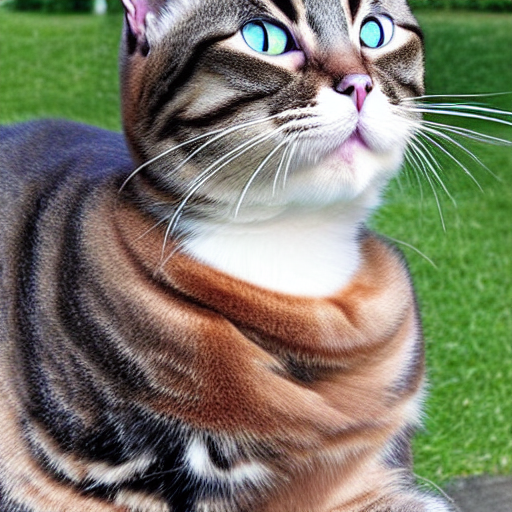

In [17]:
prompt_2 = 'A realistic cat'
imagen_2 = generar_imagen(prompt_2, '02_apariencia')
display(imagen_2)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

## Paso 3 · Atributo

**Prompt**

> `A realistic orange cat`

**Predicción:** ¿Cambiará únicamente el color o también otros rasgos?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

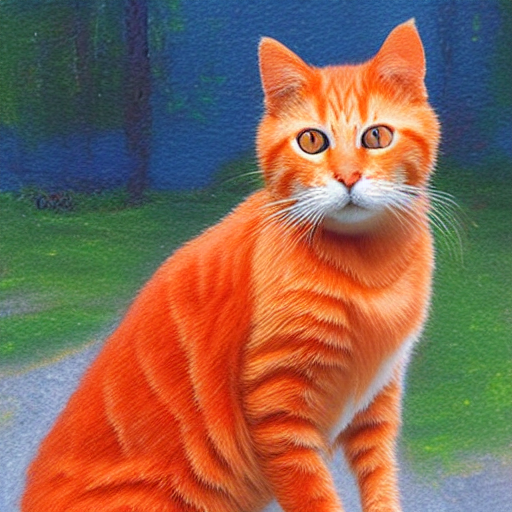

In [18]:
prompt_3 = 'A realistic orange cat'
imagen_3 = generar_imagen(prompt_3, '03_atributo')
display(imagen_3)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

## Paso 4 · Acción y objeto

**Prompt**

> `A realistic orange cat sitting on a chair`

**Predicción:** ¿Cómo puede cambiar la composición al agregar una acción y un objeto?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

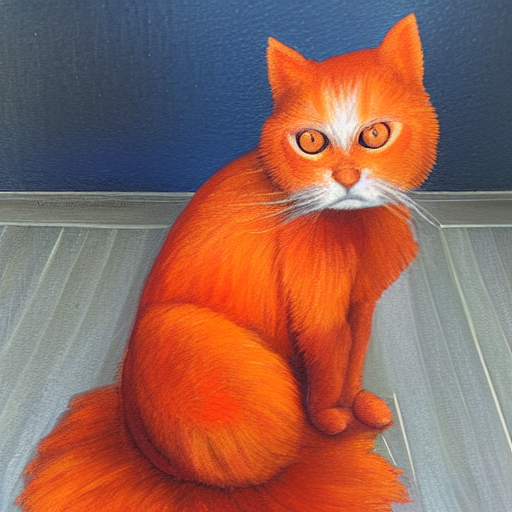

In [19]:
prompt_4 = 'A realistic orange cat sitting on a chair'
imagen_4 = generar_imagen(prompt_4, '04_accion')
display(imagen_4)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

## Paso 5 · Contexto

**Prompt**

> `A realistic orange cat sitting on a chair in a cozy coffee shop`

**Predicción:** ¿Qué objetos podría agregar el modelo aunque no se mencionen?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

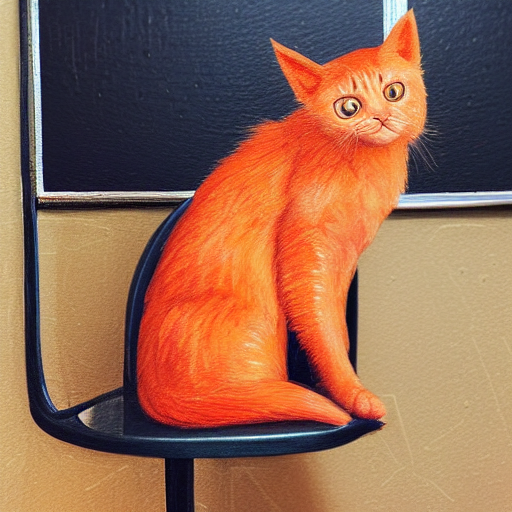

In [20]:
prompt_5 = 'A realistic orange cat sitting on a chair in a cozy coffee shop'
imagen_5 = generar_imagen(prompt_5, '05_contexto')
display(imagen_5)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

## Paso 6 · Estilo visual

**Prompt**

> `A realistic orange cat sitting on a chair in a cozy coffee shop, cinematic lighting, 35mm photography, highly detailed`

**Predicción:** ¿Qué términos controlan ahora la apariencia visual y no el contenido?

Escribe una respuesta breve antes de ejecutar.

  0%|          | 0/25 [00:00<?, ?it/s]

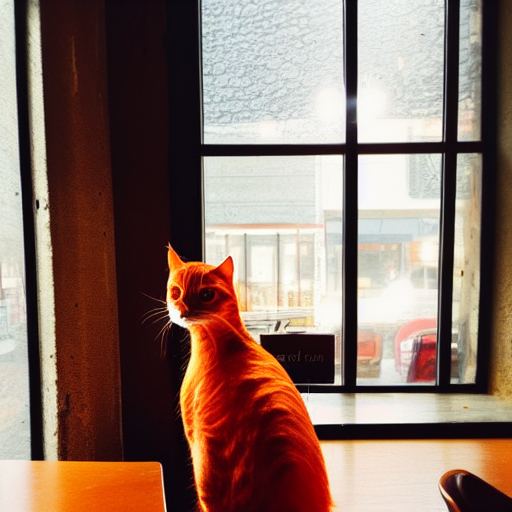

In [21]:
prompt_6 = 'A realistic orange cat sitting on a chair in a cozy coffee shop, cinematic lighting, 35mm photography, highly detailed'
imagen_6 = generar_imagen(prompt_6, '06_estilo')
display(imagen_6)

### Registro de observación

- Cambio principal:
- Elemento que permaneció:
- Elemento inesperado:
- ¿El modelo obedeció completamente el prompt?:
- Nivel de satisfacción con el resultado, de 1 a 5:

# 5. Comparación conjunta

Observa las seis imágenes como una secuencia.

> Identifica el momento en que cambia principalmente:
> - el contenido;
> - la composición;
> - el contexto;
> - el estilo.

In [12]:
imagenes = [imagen_1, imagen_2, imagen_3, imagen_4, imagen_5, imagen_6]
titulos = [
    "1. Sujeto",
    "2. Apariencia",
    "3. Atributo",
    "4. Acción",
    "5. Contexto",
    "6. Estilo"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, imagen, titulo in zip(axes.ravel(), imagenes, titulos):
    ax.imshow(imagen)
    ax.set_title(titulo)
    ax.axis("off")

plt.tight_layout()
ruta_comparacion = CARPETA_RESULTADOS / "comparacion_prompts.png"
plt.savefig(ruta_comparacion, dpi=150, bbox_inches="tight")
plt.show()

print("Comparación guardada en:", ruta_comparacion)

Output hidden; open in https://colab.research.google.com to view.

# 6. Discusión guiada

Responde con base en lo observado.

### 1. ¿Qué adición produjo el cambio más evidente?

### 2. ¿Agregar palabras mejoró siempre la imagen?

### 3. ¿Qué detalles aparecieron sin haber sido solicitados?

### 4. ¿Qué parte del prompt controló principalmente el contenido?

### 5. ¿Qué parte controló principalmente el estilo?

### 6. ¿Por qué fue importante conservar la misma semilla?

### 7. ¿Qué limitación observaste en la obediencia del modelo?



# 7. Mini reto controlado

Modifica una sola dimensión:

- sujeto;
- contexto;
- acción;
- iluminación;
- estilo.

No cambies dos dimensiones al mismo tiempo.


In [ ]:
# Modifica únicamente una dimensión del prompt.
prompt_reto = (
    "A realistic orange cat sitting on a chair in a cozy coffee shop, "
    "watercolor painting, highly detailed"
)

imagen_reto = generar_imagen(prompt_reto, "07_mini_reto")
display(imagen_reto)

## Reflexión del mini reto

- Dimensión modificada:
- Cambio realizado:
- Resultado esperado:
- Resultado observado:
- Efectos secundarios no planeados:
- ¿Repetirías el prompt? ¿Qué cambiarías?:

# 8. Cierre conceptual

Un prompt puede organizarse como:

**sujeto + atributos + acción + contexto + composición + estilo**

Sin embargo, el modelo:

- no ejecuta instrucciones como un programa;
- interpreta patrones probabilísticos;
- puede ignorar parte del texto;
- puede añadir detalles;
- puede resolver ambigüedades de maneras inesperadas.

> **Breve reflexión:**  
> “Un buen prompt no garantiza control absoluto. Lo que hace es aumentar la probabilidad de que ciertos elementos aparezcan. Por eso hablamos de orientar al modelo, no de programarlo.”

# 9. Evidencia de aprendizaje

Entrega:

1. cuadrícula comparativa;
2. imagen del mini reto;
3. respuestas de discusión;
4. conclusión personal de máximo 100 palabras.


Al finalizar la actividad, deberías poder explicar, con tus propias palabras, que:

- un prompt tiene componentes;
- el modelo completa información faltante;
- la especificidad modifica el resultado;
- mayor longitud no implica necesariamente mejor calidad;
- la generación es probabilística;
- comparar requiere controlar variables.